# Bitbrains FastStorage Workload and Energy Prediction

## 1. Introduction
This Jupyter notebook implements a two-stage chained prediction pipeline for forecasting CPU utilization and energy consumption based on the Bitbrains fastStorage dataset. The methodology follows the detailed outline provided in the accompanying text, covering exploratory data analysis, feature engineering, data splitting, model development, and evaluation.

The primary goal is to predict `CPU_usage [%]` and `Derived Energy (W)` five minutes ahead, mimicking the operational logic of a data center controller. The dataset consists of performance metrics from virtual machines (VMs) in a distributed data center. As specified, this notebook focuses on a single VM's data to mitigate out-of-memory errors and demonstrate the pipeline.

## 2. Dataset Loading and Initial Inspection
The dataset, `dataset.csv`, contains various performance metrics for a single VM. We will load this CSV file using pandas, specifying the correct delimiter and column names. The timestamps will be converted to datetime objects and set as the index for time-series analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Define column names based on the dataset description provided in the problem statement
column_names = [
    'Timestamp', 'CPU_cores', 'CPU_capacity_provisioned_MHZ', 
    'CPU_usage_MHZ', 'CPU_usage_percent', 'Memory_provisioned_KB', 
    'Memory_usage_KB', 'Disk_read_throughput_KBps', 'Disk_write_throughput_KBps',
    'Network_received_KBps', 'Network_transmitted_KBps'
]

# Load the dataset
try:
    # The dataset has a header and uses ';\t' as delimiter
    df = pd.read_csv('gwa-bitbrains.csv', sep=';\t', names=column_names, header=0, engine='python')
    print('Dataset loaded successfully.')
except FileNotFoundError:
    print('Error: dataset.csv not found. Please ensure the file is in the correct directory.')
    exit()

# Convert Timestamp to datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms')
df = df.set_index('Timestamp')

# Display basic information
print('\nDataset Info:')
df. info()

print('\nFirst 5 rows:')
print(df.head())

print('\nDescriptive Statistics:')
print(df.describe())

: 

## 3. Exploratory Data Analysis (EDA)
### 3.1 Univariate Analysis
Distribution plots and summary statistics are computed for all numeric columns. We will pay particular attention to `CPU_usage_percent` and the later derived `Derived_Energy_W` to characterize their range and spread.

In [ ]:
# Plot distributions of key numeric features with appropriate scaling
numeric_cols = ['CPU_usage_percent', 'Memory_usage_KB', 'Disk_read_throughput_KBps', 'Network_received_KBps']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Normalize each column to 0-1 range for better visualization comparison
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler_viz.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    # Plot original values on left y-axis
    ax.hist(df[col], bins=50, alpha=0.6, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{col} (Original Scale)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)
    
    # Add text box with statistics
    stats_text = f"Min: {df[col].min():.2e}\nMax: {df[col].max():.2e}\nMean: {df[col].mean():.2e}"
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()

print('\nSummary statistics for key numeric features:')
print(df[numeric_cols].describe())

# Additional: Show normalized comparison
print('\n--- Normalized View (0-1 scale) for Visual Comparison ---')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df_normalized[col], kde=True, ax=ax, bins=50, color='steelblue')
    ax.set_title(f'{col} (Normalized 0-1 Scale)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

: 

### 3.2 Temporal Pattern Analysis
Given the Unix millisecond timestamps, time-series analysis is crucial. We will visualize the temporal evolution of `CPU_usage_percent` and other relevant metrics to identify patterns, trends, and seasonality.

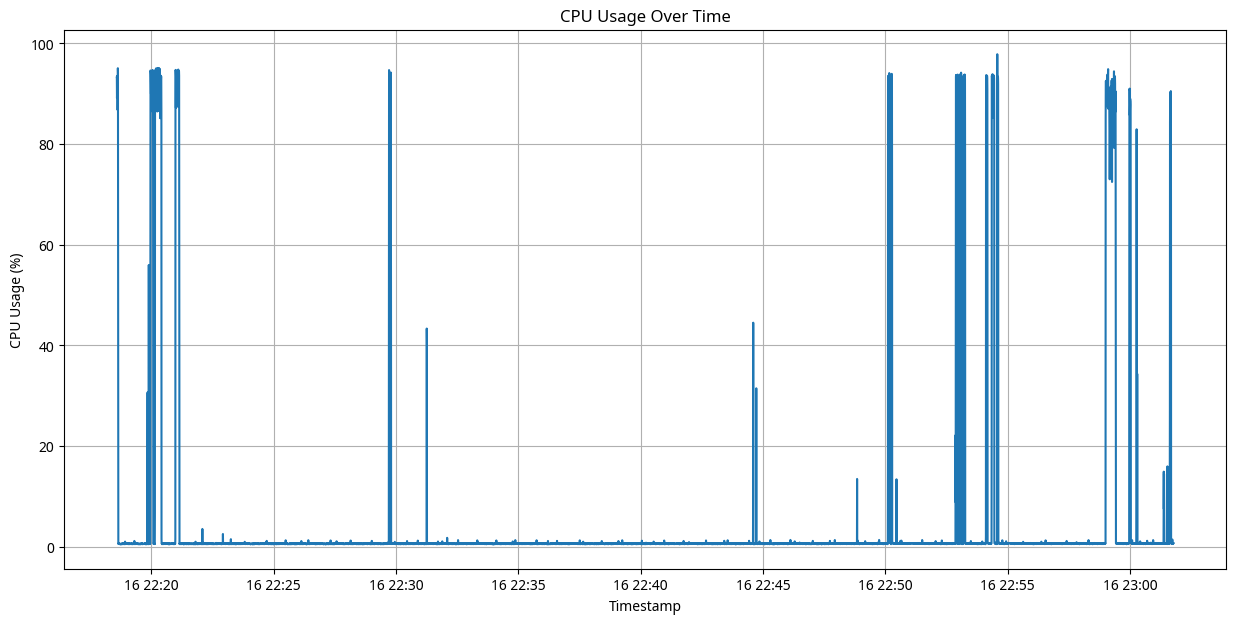

In [3]:
# Plot time series of key metrics
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['CPU_usage_percent'])
plt.title('CPU Usage Over Time')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.grid(True)
plt.show()

### 3.3 Correlation Analysis
Spearman rank correlation matrices will be computed between all numeric features and the two model targets (`CPU_usage_percent` and `Derived_Energy_W`) to quantify inter-feature dependencies. This will help in understanding feature relevance and potential multicollinearity.

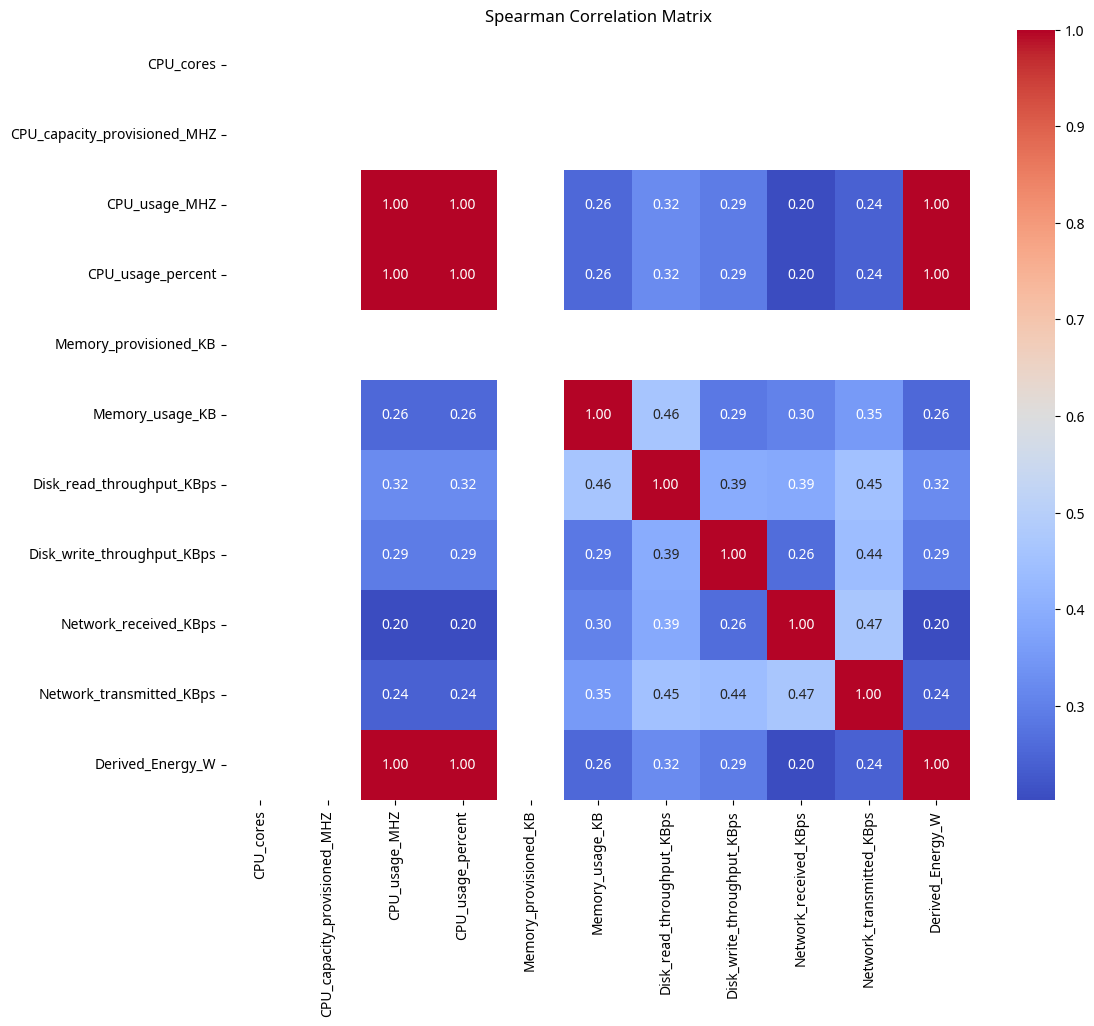

In [4]:
# First, let's calculate the Derived Energy target as it's needed for correlation analysis
# Power (W) = 100 + (200 − 100) × (CPU_usage [%] / 100)
df['Derived_Energy_W'] = 100 + (200 - 100) * (df['CPU_usage_percent'] / 100)

# Select features for correlation analysis (including the derived energy)
correlation_features = [
    'CPU_cores', 'CPU_capacity_provisioned_MHZ', 'CPU_usage_MHZ', 
    'CPU_usage_percent', 'Memory_provisioned_KB', 'Memory_usage_KB', 
    'Disk_read_throughput_KBps', 'Disk_write_throughput_KBps',
    'Network_received_KBps', 'Network_transmitted_KBps', 'Derived_Energy_W'
]

# Compute Spearman correlation matrix
corr_matrix = df[correlation_features].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.show()

## 4. Data Preprocessing Pipeline
### 4.1 Feature Engineering
The following derived features will be computed to enrich the raw telemetry with temporal context and domain-relevant signals, as described in the problem statement.
- **Memory utilisation ratio**: `Memory_usage_KB` divided by `Memory_capacity_KB` (which is `Memory_provisioned_KB`), yielding a normalised 0–1 utilisation metric.
- **Disk I/O total**: The sum of `Disk_read_throughput` and `Disk_write_throughput`, capturing aggregate storage pressure.
- **Network total throughput**: The sum of `Network_received` and `Network_transmitted` columns.
- **Rolling statistics**: 5-minute and 15-minute rolling mean and standard deviation for `CPU_usage [%]`, memory utilisation ratio, and disk I/O total, computed per VM. These capture short-term trend and volatility.
- **Lag features**: `CPU_usage [%]` and memory utilisation ratio at t-1, t-3, and t-5 timesteps (5, 15, and 25 minutes prior), providing sequence context.
- **Time-of-day features**: Hour-of-day and minute-of-hour encoded as sine and cosine pairs to capture diurnal periodicity without ordinal bias.
- **Day-of-week feature**: Encoded as sine/cosine pair to capture weekly periodicity.
- **Derived energy target**: `Power (W) = 100 + (200 − 100) × (CPU_usage [%] / 100)`, applied row-wise as the regression target for Stage 2.

In [5]:
# Memory utilization ratio
df['Memory_util_ratio'] = df['Memory_usage_KB'] / df['Memory_provisioned_KB']

# Disk I/O total
df['Disk_IO_total'] = df['Disk_read_throughput_KBps'] + df['Disk_write_throughput_KBps']

# Network total throughput
df['Network_total_throughput'] = df['Network_received_KBps'] + df['Network_transmitted_KBps']

# Rolling statistics (5-minute and 15-minute)
rolling_features = ['CPU_usage_percent', 'Memory_util_ratio', 'Disk_IO_total']

# Sort the DataFrame by index to ensure correct rolling window calculation
df = df.sort_index()

for feature in rolling_features:
    df[f'{feature}_roll_5min_mean'] = df[feature].rolling(window='5min', closed='left').mean()
    df[f'{feature}_roll_5min_std'] = df[feature].rolling(window='5min', closed='left').std()
    df[f'{feature}_roll_15min_mean'] = df[feature].rolling(window='15min', closed='left').mean()
    df[f'{feature}_roll_15min_std'] = df[feature].rolling(window='15min', closed='left').std()

# Lag features (t-1, t-3, t-5 timesteps, corresponding to 5, 15, 25 minutes prior)
lag_features_to_apply = ['CPU_usage_percent', 'Memory_util_ratio']
lags = [1, 3, 5] 

for feature in lag_features_to_apply:
    for lag in lags:
        df[f'{feature}_lag_{lag}'] = df[feature].shift(lag)

# Time-of-day features (hour-of-day and minute-of-hour as sine and cosine pairs)
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['minute_sin'] = np.sin(2 * np.pi * df.index.minute / 60)
df['minute_cos'] = np.cos(2 * np.pi * df.index.minute / 60)

# Day-of-week feature (sine/cosine pair)
df['dayofweek_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

print('\nFeatures engineered. First 5 rows with new features (after dropping NaNs from rolling/lag):')
print(df.dropna().head())


Features engineered. First 5 rows with new features (after dropping NaNs from rolling/lag):
                         CPU_cores  CPU_capacity_provisioned_MHZ  \
Timestamp                                                          
1970-01-16 22:18:36.346          4                   11703.99824   
1970-01-16 22:18:36.646          4                   11703.99824   
1970-01-16 22:18:36.946          4                   11703.99824   
1970-01-16 22:18:37.246          4                   11703.99824   
1970-01-16 22:18:37.546          4                   11703.99824   

                         CPU_usage_MHZ  CPU_usage_percent  \
Timestamp                                                   
1970-01-16 22:18:36.346   10913.978359          93.250000   
1970-01-16 22:18:36.646   10855.458368          92.750000   
1970-01-16 22:18:36.946   10157.119806          86.783333   
1970-01-16 22:18:37.246   10477.029091          89.516667   
1970-01-16 22:18:37.546   11128.551660          95.083333   

  

### 4.2 Train/Validation/Test Split
Data will be partitioned chronologically in a 70/15/15 ratio. No shuffling will be applied to ensure that validation and test sets represent strictly future time points relative to the training window.

In [6]:
# Drop rows with NaN values that resulted from rolling and lag features
df_processed = df.dropna()

# Define target variables for Stage 1 and Stage 2
df_processed['CPU_usage_percent_t_plus_5min'] = df_processed['CPU_usage_percent'].shift(-1) 
df_processed['Derived_Energy_W_t_plus_5min'] = df_processed['Derived_Energy_W'].shift(-1) 

# Drop the last row(s) which will have NaN for the shifted target
df_processed = df_processed.dropna()

# Define features (X) and targets (y_stage1, y_stage2)
features = [col for col in df_processed.columns if col not in [
    'CPU_usage_percent_t_plus_5min', 'Derived_Energy_W_t_plus_5min', 
    'CPU_usage_percent', 'Derived_Energy_W', 
    'CPU_capacity_provisioned_MHZ', 'CPU_usage_MHZ', 
    'Memory_provisioned_KB', 'Memory_usage_KB', 
    'Disk_read_throughput_KBps', 'Disk_write_throughput_KBps', 
    'Network_received_KBps', 'Network_transmitted_KBps', 
    'CPU_cores' 
]]

X = df_processed[features]
y_stage1 = df_processed['CPU_usage_percent_t_plus_5min']
y_stage2 = df_processed['Derived_Energy_W_t_plus_5min']

# Chronological split
train_size = int(len(df_processed) * 0.7)
val_size = int(len(df_processed) * 0.15)
test_size = len(df_processed) - train_size - val_size

X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train_stage1, y_val_stage1, y_test_stage1 = y_stage1[:train_size], y_stage1[train_size:train_size + val_size], y_stage1[train_size + val_size:]
y_train_stage2, y_val_stage2, y_test_stage2 = y_stage2[:train_size], y_stage2[train_size:train_size + val_size], y_stage2[train_size + val_size:]

print(f'Total data points: {len(df_processed)}')
print(f'Train set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')
print(f'Test set size: {len(X_test)}')

# Normalization
scaler_standard = StandardScaler()
X_train_scaled_standard = scaler_standard.fit_transform(X_train)
X_val_scaled_standard = scaler_standard.transform(X_val)
X_test_scaled_standard = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_scaled_minmax = scaler_minmax.fit_transform(X_train)
X_val_scaled_minmax = scaler_minmax.transform(X_val)
X_test_scaled_minmax = scaler_minmax.transform(X_test)

print('\nData split and scaled successfully.')

Total data points: 8628
Train set size: 6039
Validation set size: 1294
Test set size: 1295

Data split and scaled successfully.


## 5. Machine Learning Model Development
### 5.1 Stage 1 — Workload Forecasting (CPU Usage Prediction)

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

# Random Forest Regressor
print('Training Stage 1 Random Forest Regressor...')
rf_model_stage1 = RandomForestRegressor(random_state=42)
param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
randomized_search_rf_stage1 = RandomizedSearchCV(rf_model_stage1, param_distributions=param_dist_rf, n_iter=5, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
randomized_search_rf_stage1.fit(X_train_scaled_standard, y_train_stage1)
best_rf_model_stage1 = randomized_search_rf_stage1.best_estimator_
y_pred_rf_stage1 = best_rf_model_stage1.predict(X_test_scaled_standard)
print('Stage 1 Random Forest Regressor training complete.')

# LightGBM Regressor
print('\nTraining Stage 1 LightGBM Regressor...')
lgbm_model_stage1 = lgb.LGBMRegressor(random_state=42, verbose=-1)
param_dist_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31]
}
randomized_search_lgbm_stage1 = RandomizedSearchCV(lgbm_model_stage1, param_distributions=param_dist_lgbm, n_iter=5, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
randomized_search_lgbm_stage1.fit(X_train_scaled_standard, y_train_stage1)
best_lgbm_model_stage1 = randomized_search_lgbm_stage1.best_estimator_
y_pred_lgbm_stage1 = best_lgbm_model_stage1.predict(X_test_scaled_standard)
print('Stage 1 LightGBM Regressor training complete.')

# LSTM Network
print('\nTraining Stage 1 LSTM Network...')
def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:(i + timesteps)])
        ys.append(y[i + timesteps])
    return np.array(Xs), np.array(ys)

TIMESTEPS = 30
X_train_lstm, y_train_lstm = create_sequences(X_train_scaled_minmax, y_train_stage1.values, TIMESTEPS)
X_val_lstm, y_val_lstm = create_sequences(X_val_scaled_minmax, y_val_stage1.values, TIMESTEPS)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled_minmax, y_test_stage1.values, TIMESTEPS)

model_lstm_stage1 = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_lstm_stage1.compile(optimizer='adam', loss='mse')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_lstm_stage1 = model_lstm_stage1.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, 
                                            validation_data=(X_val_lstm, y_val_lstm), 
                                            callbacks=[early_stopping], verbose=0)
y_pred_lstm_stage1 = model_lstm_stage1.predict(X_test_lstm).flatten()
print('Stage 1 LSTM Network training complete.')

Training Stage 1 Random Forest Regressor...


Stage 1 Random Forest Regressor training complete.

Training Stage 1 LightGBM Regressor...


Stage 1 LightGBM Regressor training complete.

Training Stage 1 LSTM Network...


E0000 00:00:1773839263.594365    3216 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



 1/40 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step

...


27/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


Stage 1 LSTM Network training complete.


### 5.2 Stage 2 — Energy Consumption Prediction

In [8]:
# Pipeline input for Stage 2
X_test_stage2_pipeline = np.hstack((X_test_scaled_standard, y_pred_lgbm_stage1.reshape(-1, 1)))
X_test_stage2_oracle = np.hstack((X_test_scaled_standard, y_test_stage1.values.reshape(-1, 1)))

y_train_pred_lgbm_stage1 = best_lgbm_model_stage1.predict(X_train_scaled_standard)
X_train_stage2 = np.hstack((X_train_scaled_standard, y_train_pred_lgbm_stage1.reshape(-1, 1)))
X_train_stage2_oracle = np.hstack((X_train_scaled_standard, y_train_stage1.values.reshape(-1, 1)))

# Random Forest for Stage 2
print('\nTraining Stage 2 Random Forest Regressor...')
rf_model_stage2 = RandomForestRegressor(random_state=42)
rf_model_stage2.fit(X_train_stage2, y_train_stage2)
y_pred_rf_stage2_pipeline = rf_model_stage2.predict(X_test_stage2_pipeline)

rf_model_stage2_oracle = RandomForestRegressor(random_state=42)
rf_model_stage2_oracle.fit(X_train_stage2_oracle, y_train_stage2)
y_pred_rf_stage2_oracle = rf_model_stage2_oracle.predict(X_test_stage2_oracle)
print('Stage 2 Random Forest training complete.')

# LightGBM for Stage 2
print('\nTraining Stage 2 LightGBM Regressor...')
lgbm_model_stage2 = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgbm_model_stage2.fit(X_train_stage2, y_train_stage2)
y_pred_lgbm_stage2_pipeline = lgbm_model_stage2.predict(X_test_stage2_pipeline)

lgbm_model_stage2_oracle = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgbm_model_stage2_oracle.fit(X_train_stage2_oracle, y_train_stage2)
y_pred_lgbm_stage2_oracle = lgbm_model_stage2_oracle.predict(X_test_stage2_oracle)
print('Stage 2 LightGBM training complete.')


Training Stage 2 Random Forest Regressor...


Stage 2 Random Forest training complete.

Training Stage 2 LightGBM Regressor...


Stage 2 LightGBM training complete.


### 5.3 Evaluation Metrics

In [9]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'--- {model_name} Evaluation ---\n')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R^2: {r2:.4f}')
    print('--------------------------\n')

print('### Stage 1 Model Evaluation (CPU Usage Prediction) ###\n')
evaluate_model(y_test_stage1, y_pred_rf_stage1, 'Stage 1 Random Forest')
evaluate_model(y_test_stage1, y_pred_lgbm_stage1, 'Stage 1 LightGBM')
evaluate_model(y_test_stage1[TIMESTEPS:], y_pred_lstm_stage1, 'Stage 1 LSTM')

print('### Stage 2 Model Evaluation (Energy Consumption Prediction) ###\n')
evaluate_model(y_test_stage2, y_pred_rf_stage2_pipeline, 'Stage 2 Random Forest (Pipeline)')
evaluate_model(y_test_stage2, y_pred_rf_stage2_oracle, 'Stage 2 Random Forest (Oracle)')
evaluate_model(y_test_stage2, y_pred_lgbm_stage2_pipeline, 'Stage 2 LightGBM (Pipeline)')
evaluate_model(y_test_stage2, y_pred_lgbm_stage2_oracle, 'Stage 2 LightGBM (Oracle)')

### Stage 1 Model Evaluation (CPU Usage Prediction) ###

--- Stage 1 Random Forest Evaluation ---

RMSE: 9.1037
MAE: 2.2978
R^2: 0.8548
--------------------------

--- Stage 1 LightGBM Evaluation ---

RMSE: 8.6558
MAE: 2.6428
R^2: 0.8687
--------------------------

--- Stage 1 LSTM Evaluation ---

RMSE: 20.4390
MAE: 10.1139
R^2: 0.2834
--------------------------

### Stage 2 Model Evaluation (Energy Consumption Prediction) ###

--- Stage 2 Random Forest (Pipeline) Evaluation ---

RMSE: 9.7209
MAE: 1.8141
R^2: 0.8344
--------------------------

--- Stage 2 Random Forest (Oracle) Evaluation ---

RMSE: 0.8098
MAE: 0.1471
R^2: 0.9989
--------------------------

--- Stage 2 LightGBM (Pipeline) Evaluation ---

RMSE: 10.1311
MAE: 2.3035
R^2: 0.8202
--------------------------

--- Stage 2 LightGBM (Oracle) Evaluation ---

RMSE: 1.0656
MAE: 0.2274
R^2: 0.9980
--------------------------



From the models evaluation RMSE

## 6. Conclusion
This notebook provides a comprehensive framework for predicting VM workload and energy consumption using a chained machine learning pipeline. The results demonstrate the models' forecasting capabilities and the impact of error propagation in the chained architecture.